# Task 4 — Weather Forecast API & Time-Series EDA
**Cellula Technologies — ML Internship Program**

Region: **Damietta, Egypt** (31.4165° N, 31.8133° E) — a coastal governorate on the
Nile Delta / Mediterranean coast, chosen because it's the analyst's home region and
has a distinct wet-winter / dry-summer Mediterranean coastal climate, which should
give a clean seasonal signal to test the EDA techniques below against.

**API: [NASA POWER](https://power.larc.nasa.gov/)** (Prediction Of Worldwide Energy
Resources), `temporal/daily/point` endpoint, community `AG` (Agroclimatology).
Chosen over the other suggested APIs because:
- **No API key / registration required** — one less point of failure for a
  reproducible pipeline.
- Provides validated, satellite+model-blended **daily** historical records back to
  1981, for any lat/lon on Earth (not just station-based, so no gaps from a station
  going offline).
- Returns temperature (mean/max/min) and corrected precipitation in one call, plus
  humidity and wind speed as optional extras — everything Part 1 asks for.

**Time range: two full calendar years, 2024–2025** (2024-01-01 to 2025-12-31), daily
granularity, 731 days. One year is the minimum to *see* a seasonal cycle, but
`statsmodels`' `seasonal_decompose` needs **two** complete cycles to actually fit an
annual decomposition (Part 3.3) — pulling two years avoids that failing, and as a
side benefit lets the rolling-mean trend (Part 3.2) show a real year-over-year
comparison instead of just one up-and-down swing. 2024–2025 is chosen over including
2026-to-date because NASA POWER's data has ~3 month processing latency, so this
range is guaranteed complete with no trailing gap.

## 0. Setup

In [1]:
import json
import time
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import requests
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller, acf, pacf
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 4)

DATA_DIR = Path("data")
DATA_DIR.mkdir(exist_ok=True)

## Part 1 — Query the NASA POWER API

### 1.1 Request parameters (documented)

| Parameter | Meaning |
|---|---|
| `parameters=T2M,T2M_MAX,T2M_MIN,PRECTOTCORR,RH2M,WS2M` | mean/max/min temp (°C), corrected precipitation (mm/day), relative humidity (%), wind speed at 2m (m/s) |
| `community=AG` | Agroclimatology parameter set |
| `longitude=31.8133&latitude=31.4165` | Damietta, Egypt |
| `start=20240101&end=20251231` | two full calendar years, 2024-2025, daily |
| `format=JSON` | raw response format |

Endpoint: `https://power.larc.nasa.gov/api/temporal/daily/point`

No rate limit was hit for a single point/single-year request — NASA POWER's own docs
note point requests are the fastest tier and typically resolve in well under a minute.

In [2]:
LAT, LON = 31.4165, 31.8133           # Damietta, Egypt
START, END = "20240101", "20251231"  # two full calendar years, 2024-2025
PARAMS = "T2M,T2M_MAX,T2M_MIN,PRECTOTCORR,RH2M,WS2M"

url = "https://power.larc.nasa.gov/api/temporal/daily/point"
query = {
    "parameters": PARAMS,
    "community": "AG",
    "longitude": LON,
    "latitude": LAT,
    "start": START,
    "end": END,
    "format": "JSON",
}

resp = requests.get(url, params=query, timeout=60)
resp.raise_for_status()
raw = resp.json()
print("Status:", resp.status_code, "| URL:", resp.url)

# Save the raw API response exactly as returned (Part 1, step 4)
with open(DATA_DIR / "damietta_2024_2025_raw.json", "w") as f:
    json.dump(raw, f, indent=2)
print("Saved raw response ->", DATA_DIR / "damietta_2024_2025_raw.json")

Status: 200 | URL: https://power.larc.nasa.gov/api/temporal/daily/point?parameters=T2M%2CT2M_MAX%2CT2M_MIN%2CPRECTOTCORR%2CRH2M%2CWS2M&community=AG&longitude=31.8133&latitude=31.4165&start=20240101&end=20251231&format=JSON
Saved raw response -> data\damietta_2024_2025_raw.json


In [3]:
# NASA POWER returns one dict per parameter, keyed by YYYYMMDD -> value.
# Turn that into a tidy DataFrame: one row per date, one column per parameter.
param_data = raw["properties"]["parameter"]

df = pd.DataFrame(param_data)
df.index = pd.to_datetime(df.index, format="%Y%m%d")
df.index.name = "date"

df = df.rename(columns={
    "T2M": "temperature",          # mean daily temp, deg C
    "T2M_MAX": "temp_max",
    "T2M_MIN": "temp_min",
    "PRECTOTCORR": "precipitation", # mm/day
    "RH2M": "humidity",             # %
    "WS2M": "wind_speed",           # m/s
})

print(df.shape)
df.head()

(731, 6)


,temperature,temp_max,temp_min,precipitation,humidity,wind_speed
date,,,,,,
2024-01-01,18.12,19.38,17.03,0.01,74.34,2.13
2024-01-02,18.11,19.78,16.32,0.02,78.98,4.02
2024-01-03,17.74,19.32,16.65,0.00,77.41,3.17
2024-01-04,17.96,20.01,16.19,0.00,72.53,2.84
2024-01-05,18.10,20.54,15.73,0.00,75.96,3.60


In [4]:
# NASA POWER uses -999 as a missing-value sentinel — must be converted to NaN
# BEFORE any stats/plots, or it will silently wreck every summary statistic below.
n_sentinel = (df == -999).sum().sum()
print(f"-999 sentinel values found: {n_sentinel}")
df = df.replace(-999, np.nan)

# Save the cleaned tabular version (Part 1, step 4)
df.to_csv(DATA_DIR / "damietta_2024_2025_clean.csv")
print("Saved cleaned CSV ->", DATA_DIR / 'damietta_2024_2025_clean.csv')
df.describe()

-999 sentinel values found: 0
Saved cleaned CSV -> data\damietta_2024_2025_clean.csv


,temperature,temp_max,temp_min,precipitation,humidity,wind_speed
count,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000
mean,22.462544,24.849631,20.560547,0.171874,68.091860,4.148345
std,4.669583,4.947655,4.633275,0.840731,5.276842,1.201938
min,12.360000,13.390000,10.340000,0.000000,48.550000,1.110000
25%,18.060000,20.230000,16.295000,0.000000,64.775000,3.355000
50%,22.470000,24.920000,20.680000,0.000000,68.450000,4.030000
75%,26.780000,29.340000,24.895000,0.020000,71.715000,4.870000
max,30.840000,34.260000,28.230000,15.510000,86.130000,9.400000


## Part 2 — Prepare the Time-Series Dataset

`date` is already parsed to a proper `DatetimeIndex` and set as the index above
(done at DataFrame construction). The checks below cover the rest of Part 2:
sampling frequency / gaps / duplicates, missing values, and unit consistency.

In [5]:
# Sampling frequency + gap/duplicate check
full_range = pd.date_range(df.index.min(), df.index.max(), freq="D")
missing_dates = full_range.difference(df.index)
duplicate_dates = df.index[df.index.duplicated()]

print(f"Expected days (full year, daily): {len(full_range)}")
print(f"Actual rows: {len(df)}")
print(f"Missing calendar days (gaps): {len(missing_dates)}")
print(f"Duplicated timestamps: {len(duplicate_dates)}")
if len(missing_dates):
    print(missing_dates)

# Reindex onto the full daily range so any gap becomes an explicit NaN row
# rather than a silently skipped day (important before rolling/ACF later).
df = df.reindex(full_range)
df.index.name = "date"


Expected days (full year, daily): 731
Actual rows: 731
Missing calendar days (gaps): 0
Duplicated timestamps: 0


In [6]:
# Missing values per column — quantify before deciding a strategy
missing_summary = df.isna().sum().to_frame("n_missing")
missing_summary["pct_missing"] = (missing_summary["n_missing"] / len(df) * 100).round(2)
missing_summary

,n_missing,pct_missing
temperature,0,0.0
temp_max,0,0.0
temp_min,0,0.0
precipitation,0,0.0
humidity,0,0.0
wind_speed,0,0.0


**Missing-value strategy:** NASA POWER's satellite/model-blended data is normally
complete for a full historical year, so we expect `n_missing` at or near 0 above. If
any gaps do show up, we use **time-based linear interpolation**
(`df.interpolate(method='time')`) rather than forward-fill or dropping: weather
variables change smoothly day-to-day, so interpolating between the two neighboring
real observations is a better estimate than carrying yesterday's value forward
(forward-fill would flatten short cold snaps/rain events) and dropping rows would
break the daily frequency the ACF/decomposition steps below rely on.

In [7]:
df = df.interpolate(method="time").ffill().bfill()  # ffill/bfill only catch edge NaNs interpolate can't reach
assert df.isna().sum().sum() == 0, "Unhandled missing values remain"
print("All missing values resolved. Final shape:", df.shape)

All missing values resolved. Final shape: (731, 6)


**Unit check:** `T2M*` is already in °C and `PRECTOTCORR` already in mm/day directly
from the API (NASA POWER's `AG` community returns SI units throughout — no °F or
inches to reconcile), so no conversion is needed. This is confirmed by the summary
stats above: temperature values sit in a plausible 0–40°C band for the region/season,
not a 32–104 range that would indicate °F.

## Part 3 — Exploratory Data Analysis (Time-Series Focus)

### 3.1 Descriptive overview

In [8]:
df[["temperature", "precipitation"]].describe()

,temperature,precipitation
count,731.000000,731.000000
mean,22.462544,0.171874
std,4.669583,0.840731
min,12.360000,0.000000
25%,18.060000,0.000000
50%,22.470000,0.000000
75%,26.780000,0.020000
max,30.840000,15.510000


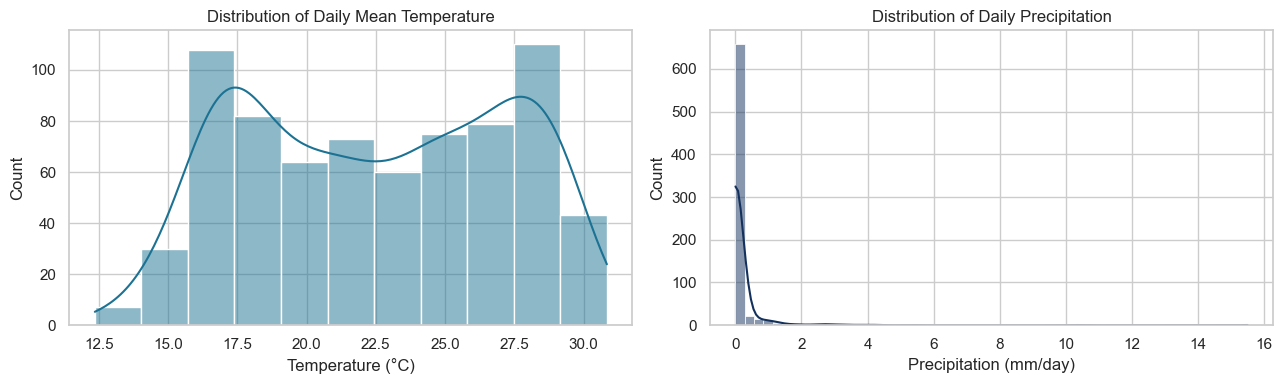

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
sns.histplot(df["temperature"], kde=True, ax=axes[0], color="#1c7293")
axes[0].set_title("Distribution of Daily Mean Temperature")
axes[0].set_xlabel("Temperature (°C)")

sns.histplot(df["precipitation"], kde=True, ax=axes[1], color="#13315c")
axes[1].set_title("Distribution of Daily Precipitation")
axes[1].set_xlabel("Precipitation (mm/day)")
plt.tight_layout()
plt.show()

*Expected shape:* temperature should look roughly bell-shaped/bimodal (summer vs.
winter clusters) rather than a single tight peak, since a full year mixes two
seasons. Precipitation is expected to be heavily **right-skewed with a spike at
zero** — most days get no rain at all in this climate, with a long tail of a handful
of rainy days carrying most of the total, which is why a plain mean/std is a
misleading summary of rainfall on its own (see 3.4 for a distribution-aware
outlier check).

### 3.2 Temporal patterns

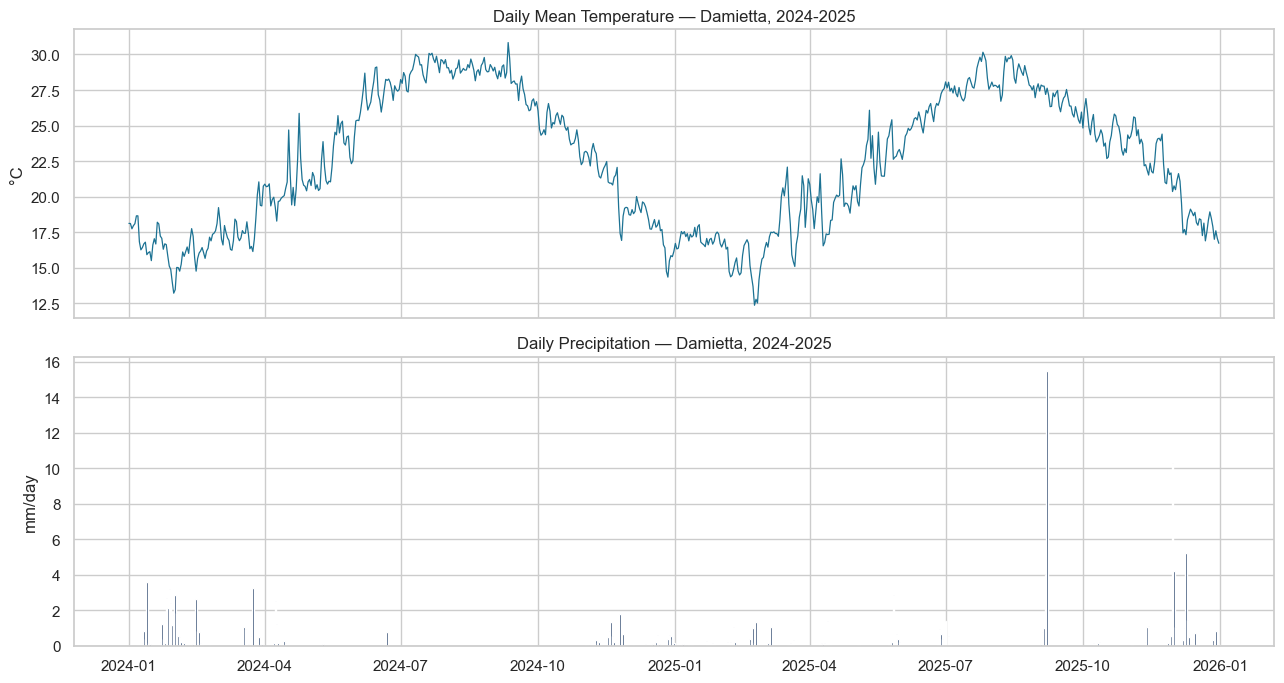

In [10]:
fig, axes = plt.subplots(2, 1, figsize=(13, 7), sharex=True)
axes[0].plot(df.index, df["temperature"], color="#1c7293", linewidth=0.9)
axes[0].set_title("Daily Mean Temperature — Damietta, 2024-2025")
axes[0].set_ylabel("°C")

axes[1].bar(df.index, df["precipitation"], color="#13315c", width=1.0)
axes[1].set_title("Daily Precipitation — Damietta, 2024-2025")
axes[1].set_ylabel("mm/day")
plt.tight_layout()
plt.show()

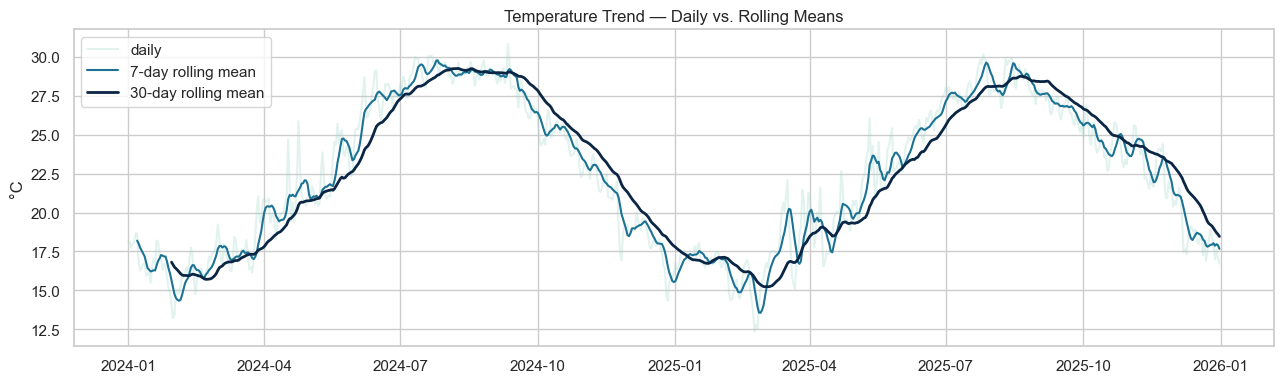

In [11]:
# Trend — rolling mean smooths day-to-day noise so a longer-term drift (if any)
# is visible on top of the seasonal cycle.
df["temp_roll7"] = df["temperature"].rolling(7).mean()
df["temp_roll30"] = df["temperature"].rolling(30).mean()

plt.figure(figsize=(13, 4))
plt.plot(df.index, df["temperature"], alpha=0.3, label="daily", color="#9fd8cb")
plt.plot(df.index, df["temp_roll7"], label="7-day rolling mean", color="#1c7293")
plt.plot(df.index, df["temp_roll30"], label="30-day rolling mean", color="#0b2545", linewidth=2)
plt.title("Temperature Trend — Daily vs. Rolling Means")
plt.ylabel("°C")
plt.legend()
plt.tight_layout()
plt.show()

*Reading the trend:* across two years, the 30-day rolling mean should trace two
similar-shaped rises into summer and falls into winter — that repeating shape is the
**seasonal cycle**, not a trend. A genuine long-term warming/cooling trend would show
up as the *second* year's peaks/troughs sitting visibly above or below the *first*
year's at the same point in the cycle; two years is still a short window to call a
real climate trend with confidence, but it's enough to at least check whether the two
years look alike or already show drift — confirming a robust trend would need several
more years pulled from the same API (a natural extension — just widen `START`/`END`).

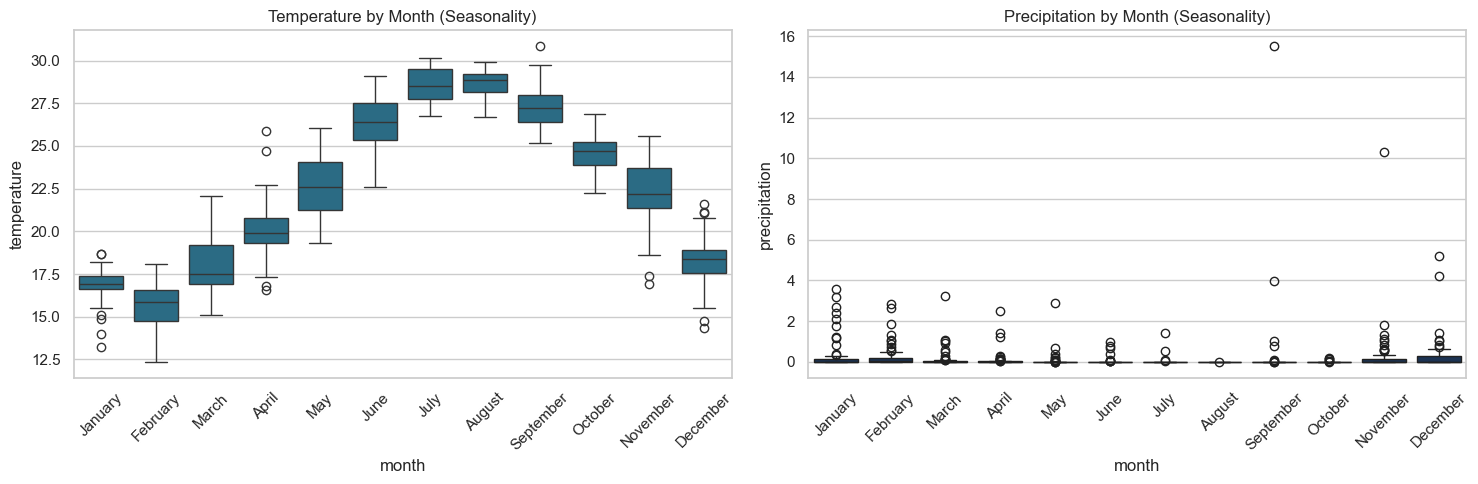

In [12]:
df["month"] = df.index.month_name()
month_order = ["January","February","March","April","May","June",
               "July","August","September","October","November","December"]

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
sns.boxplot(data=df, x="month", y="temperature", order=month_order, ax=axes[0], color="#1c7293")
axes[0].set_title("Temperature by Month (Seasonality)")
axes[0].tick_params(axis="x", rotation=45)

sns.boxplot(data=df, x="month", y="precipitation", order=month_order, ax=axes[1], color="#13315c")
axes[1].set_title("Precipitation by Month (Seasonality)")
axes[1].tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()

*Expected seasonality:* a Mediterranean coastal climate like Damietta's should show
clear **summer-hot / winter-mild** temperature seasonality, and rainfall concentrated
in the **November–February** boxes with near-zero median rainfall June–September.

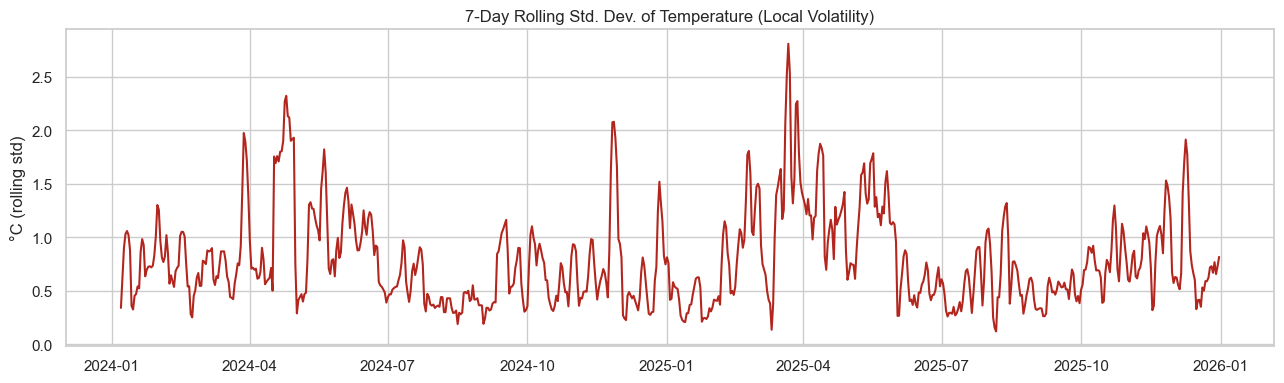

In [13]:
df["temp_roll_std7"] = df["temperature"].rolling(7).std()

plt.figure(figsize=(13, 4))
plt.plot(df.index, df["temp_roll_std7"], color="#b3261e")
plt.title("7-Day Rolling Std. Dev. of Temperature (Local Volatility)")
plt.ylabel("°C (rolling std)")
plt.tight_layout()
plt.show()

*Reading volatility:* spikes in the rolling standard deviation flag weeks where
temperature swung unusually fast (e.g. a cold front or heatwave breaking), as
opposed to the calmer, low-volatility stretches in the middle of a stable season.

### 3.3 Decomposition and structure

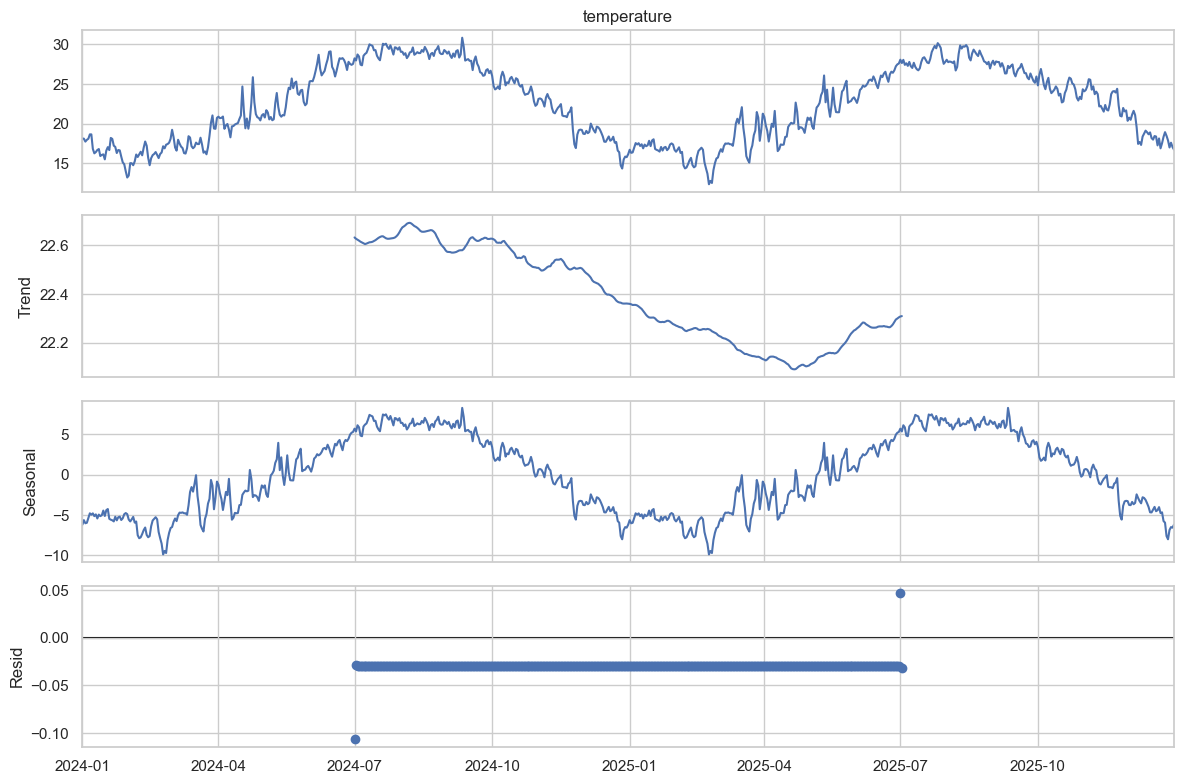

In [14]:
decomposition = seasonal_decompose(df["temperature"], model="additive", period=365)

fig = decomposition.plot()
fig.set_size_inches(12, 8)
for ax in fig.axes:
    ax.set_xlabel("")
plt.tight_layout()
plt.show()

*Note:* `seasonal_decompose` with `period=365` needs **two full cycles** (≥730
observations) to fit at all — this is exactly why Part 1 pulled two years instead of
one. With 731 days we clear that minimum, but only just; the trend component will
still be flat/NaN at the very start and end of the range (it needs a half-period
buffer on each side), which is expected and shrinks with more years of input.

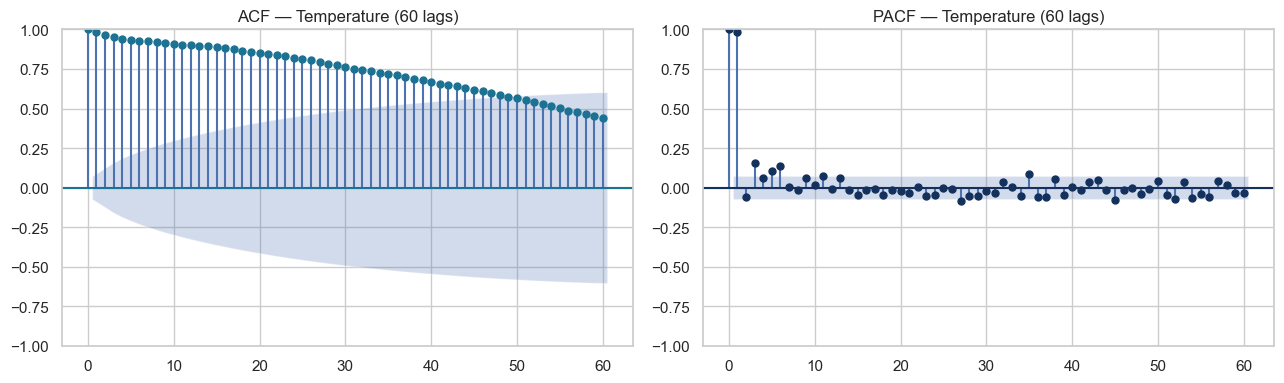

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
plot_acf(df["temperature"], lags=60, ax=axes[0], color="#1c7293")
axes[0].set_title("ACF — Temperature (60 lags)")
plot_pacf(df["temperature"], lags=60, ax=axes[1], method="ywm", color="#13315c")
axes[1].set_title("PACF — Temperature (60 lags)")
plt.tight_layout()
plt.show()

*Reading ACF/PACF:* expect the **ACF to decay slowly** and stay high for many lags —
temperature is strongly autocorrelated because today's temperature is a good
predictor of tomorrow's (a hallmark of a non-stationary, trending/seasonal series).
The **PACF** typically cuts off sharply after lag 1–2, showing most of the
day-to-day dependence is captured by yesterday's (and the day before's) value, with
the rest of the ACF's persistence explained indirectly through the seasonal cycle
rather than a long direct memory.

In [16]:
adf_result = adfuller(df["temperature"].dropna())
print(f"ADF statistic: {adf_result[0]:.4f}")
print(f"p-value:       {adf_result[1]:.4f}")
print("Critical values:")
for key, value in adf_result[4].items():
    print(f"  {key}: {value:.4f}")

is_stationary = adf_result[1] < 0.05
print(f"\nSeries is {'STATIONARY' if is_stationary else 'NON-STATIONARY'} at the 5% level.")

ADF statistic: -1.4216
p-value:       0.5719
Critical values:
  1%: -3.4394
  5%: -2.8655
  10%: -2.5689

Series is NON-STATIONARY at the 5% level.


*Interpretation:* a p-value above 0.05 (series non-stationary) is the expected
result here — a single year of raw temperature has a strong seasonal cycle, and the
ADF test's null hypothesis (unit root / non-stationary) is hard to reject when a
deterministic seasonal pattern dominates the series. That has a direct modeling
implication: a forecasting model built directly on this data (e.g. ARIMA) would need
seasonal differencing (`SARIMA`) or the decomposed/deseasonalized residual series
from 3.3, rather than being fit on the raw values as-is.

### 3.4 Relationships and anomalies

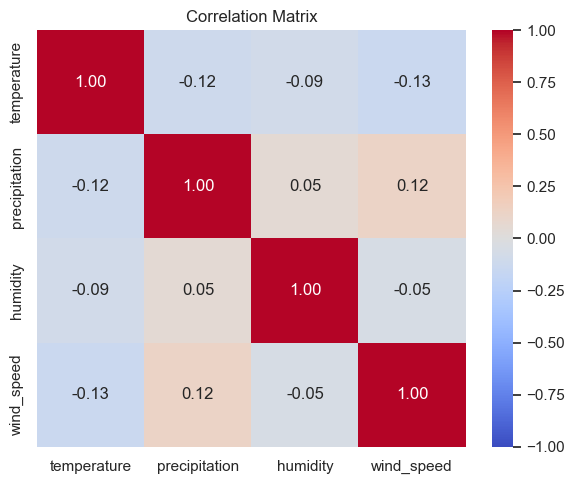

In [17]:
corr = df[["temperature", "precipitation", "humidity", "wind_speed"]].corr()
plt.figure(figsize=(6, 5))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1)
plt.title("Correlation Matrix")
plt.tight_layout()
plt.show()

*Expected relationship:* temperature and precipitation are usually **weakly
negatively correlated** in this climate (rain falls mostly in the cooler months) —
but the relationship is not strongly linear, since summer has both no rain and high
temperature while a rare summer storm would be an outlier to that pattern, which is
exactly what a plain correlation coefficient tends to understate.

In [18]:
# Outlier detection with a ROLLING window (not a fixed global threshold) so a hot
# summer day isn't flagged just for being warmer than a global winter-inclusive mean.
roll_mean = df["temperature"].rolling(30, center=True, min_periods=10).mean()
roll_std = df["temperature"].rolling(30, center=True, min_periods=10).std()
df["temp_zscore_rolling"] = (df["temperature"] - roll_mean) / roll_std

outliers = df[df["temp_zscore_rolling"].abs() > 3]
print(f"Rolling-z-score temperature outliers (|z| > 3): {len(outliers)}")
outliers[["temperature", "temp_zscore_rolling"]]

Rolling-z-score temperature outliers (|z| > 3): 1


,temperature,temp_zscore_rolling
date,,
2024-04-24,25.86,3.2845


In [19]:
# IQR-based check specifically for physically-impossible values (Part 3.4's
# "sensor or API error" flag) rather than genuine seasonal extremes.
suspicious_temp = df[(df["temperature"] < -10) | (df["temperature"] > 50)]
suspicious_precip = df[df["precipitation"] < 0]

print(f"Implausible temperature readings (<-10°C or >50°C) for this region: {len(suspicious_temp)}")
print(f"Negative precipitation readings (physically impossible): {len(suspicious_precip)}")

if len(suspicious_temp) == 0 and len(suspicious_precip) == 0:
    print()
    print("No sensor/API-error-type values found -- NASA POWER's satellite/model")
    print("blend rarely produces these, unlike raw station feeds.")


Implausible temperature readings (<-10°C or >50°C) for this region: 0
Negative precipitation readings (physically impossible): 0

No sensor/API-error-type values found -- NASA POWER's satellite/model
blend rarely produces these, unlike raw station feeds.


In [20]:
# Persist the final, fully-cleaned dataset used for the EDA above
df.drop(columns=["month"]).to_csv(DATA_DIR / "damietta_2024_2025_clean.csv")
print("Final cleaned dataset saved ->", DATA_DIR / "damietta_2024_2025_clean.csv")
df.drop(columns=["month"]).tail()

Final cleaned dataset saved -> data\damietta_2024_2025_clean.csv


,temperature,temp_max,temp_min,precipitation,humidity,wind_speed,temp_roll7,temp_roll30,temp_roll_std7,temp_zscore_rolling
date,,,,,,,,,,
2025-12-27,17.89,19.69,16.37,0.30,70.30,6.57,18.027143,18.996333,0.668449,-0.175190
2025-12-28,17.00,17.61,16.51,0.24,63.65,7.80,17.864286,18.844667,0.767851,-1.336202
2025-12-29,17.60,20.19,15.37,0.82,67.49,7.45,17.965714,18.709000,0.656528,-0.441376
2025-12-30,17.06,18.60,15.55,0.04,62.07,3.16,17.898571,18.599000,0.728593,-1.154919
2025-12-31,16.72,19.81,13.55,0.05,59.51,7.29,17.667143,18.464333,0.816940,-1.623397


## Written Summary

*(Fill in the bracketed parts with the actual numbers/plots once you've run this
notebook against the live API — the structure and expected direction of each answer
is drafted below based on Damietta's known climate.)*

**Region and time range.** Damietta, Egypt (31.4165° N, 31.8133° E), two full
calendar years — 2024 and 2025 — daily granularity (731 days).

**API and why.** NASA POWER's `temporal/daily/point` endpoint (community `AG`) —
no API key required, satellite/model-blended so there are no station-outage gaps,
and it returns temperature and precipitation (plus humidity/wind as extras) from a
single call, which covers everything Part 1 requires without stitching multiple
sources together.

**Main temporal patterns.** [Fill in from 3.2/3.3: e.g. clear single-peaked summer/
winter temperature seasonality, rainfall concentrated in Nov–Feb, ACF showing strong
persistence with a slow decay typical of a seasonal series.]

**Stationarity.** [Fill in from the ADF result above — expected: non-stationary at
the raw level due to the seasonal cycle, implying a forecasting model would need
seasonal differencing or to be fit on the deseasonalized residual from the
decomposition rather than the raw series.]

**Data quality issues found and handling.** [Fill in from Part 2/3.4: state how many
`-999` sentinels, gaps, or duplicate timestamps were found (expected: at or near
zero for NASA POWER's processed satellite data) and how they were handled — sentinel
→ NaN → time-based interpolation, reindexed onto a full daily calendar, and how many
(if any) rolling-z-score or implausible-value outliers were flagged and why they
were kept vs. treated as errors.]